In [2]:
!pip install prophet


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
from prophet import Prophet
import plotly.express as px


In [4]:
demand_df = pd.read_csv('../data/raw/historical_demand.csv')
print(demand_df.head())
store_casablanca = demand_df[demand_df['city']=='Casablanca'][['date','demand_tonnes']].copy()
store_casablanca = store_casablanca.rename(columns={'date':'ds','demand_tonnes':'y'},index=None)

         city  region  latitude  longitude  base_demand        date  month  \
0  Casablanca  Centre   33.5731    -7.5898         4500  2023-01-01      1   
1  Casablanca  Centre   33.5731    -7.5898         4500  2023-02-01      2   
2  Casablanca  Centre   33.5731    -7.5898         4500  2023-03-01      3   
3  Casablanca  Centre   33.5731    -7.5898         4500  2023-04-01      4   
4  Casablanca  Centre   33.5731    -7.5898         4500  2023-05-01      5   

   demand_tonnes  
0           4612  
1           4469  
2           6039  
3           4843  
4           4447  


In [5]:
model = Prophet(seasonality_mode='multiplicative',yearly_seasonality=True)
model.fit(store_casablanca)
future = model.make_future_dataframe(periods=13,freq='MS')
print(future)
forecast = model.predict(future)

18:07:19 - cmdstanpy - INFO - Chain [1] start processing
18:07:30 - cmdstanpy - INFO - Chain [1] done processing


           ds
0  2023-01-01
1  2023-02-01
2  2023-03-01
3  2023-04-01
4  2023-05-01
5  2023-06-01
6  2023-07-01
7  2023-08-01
8  2023-09-01
9  2023-10-01
10 2023-11-01
11 2023-12-01
12 2024-01-01
13 2024-02-01
14 2024-03-01
15 2024-04-01
16 2024-05-01
17 2024-06-01
18 2024-07-01
19 2024-08-01
20 2024-09-01
21 2024-10-01
22 2024-11-01
23 2024-12-01
24 2025-01-01
25 2025-02-01
26 2025-03-01
27 2025-04-01
28 2025-05-01
29 2025-06-01
30 2025-07-01
31 2025-08-01
32 2025-09-01
33 2025-10-01
34 2025-11-01
35 2025-12-01
36 2026-01-01


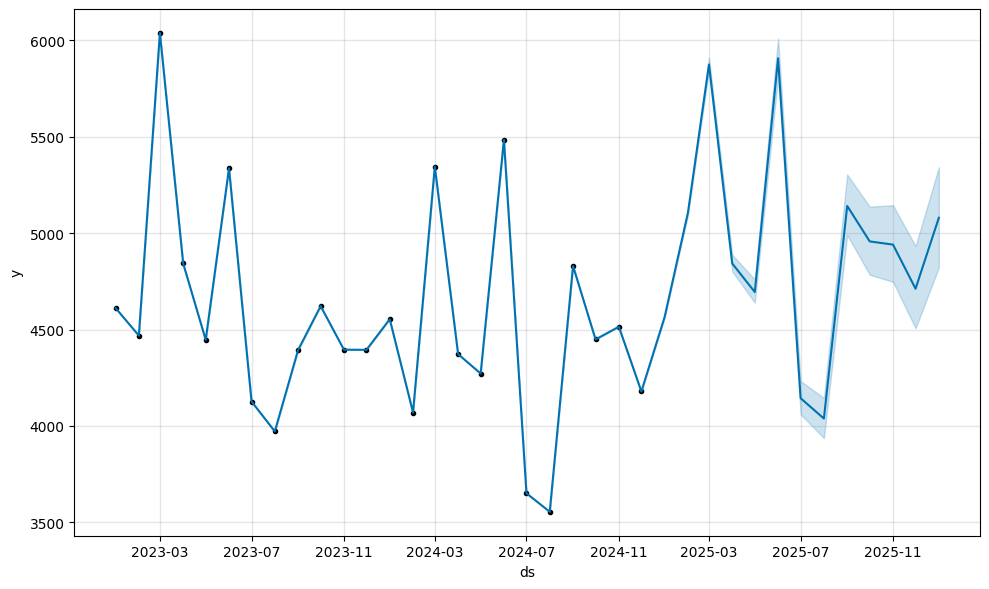

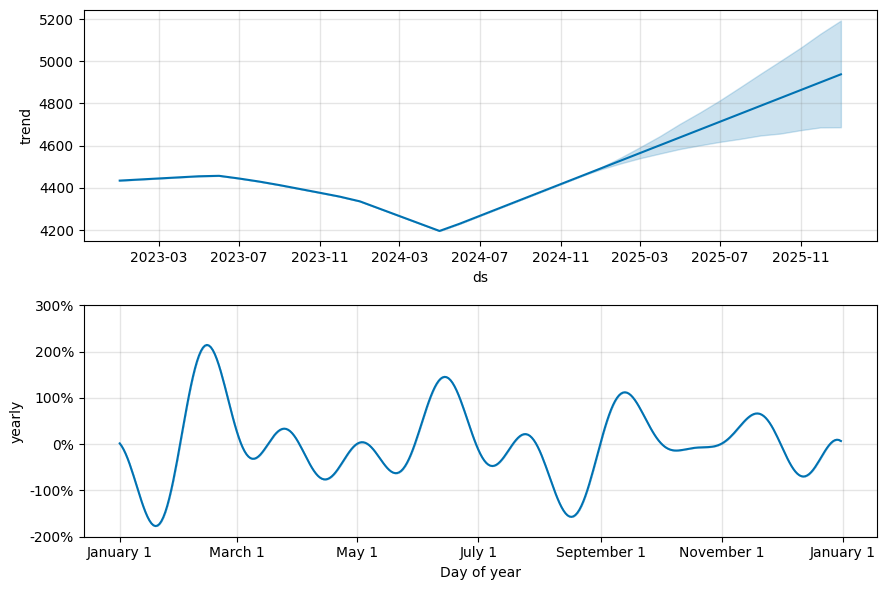

In [7]:
fig = model.plot(forecast)
fig2 = model.plot_components(forecast)

In [ ]:
cities = demand_df['city'].unique()
results = []

for city in cities:
    df = demand_df[demand_df['city'] == city][['date', 'demand_tonnes']].copy()
    df = df.rename(columns={'date': 'ds', 'demand_tonnes': 'y'})
    model = Prophet(seasonality_mode='multiplicative',yearly_seasonality=True)
    model.fit(df)
    future = model.make_future_dataframe(periods=13,freq='MS')
    forecast = model.predict(future)
    forecast['city'] = city
    results.append(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'city']])
all_forecasts = pd.concat(results)
print(all_forecasts.shape)

23:20:29 - cmdstanpy - INFO - Chain [1] start processing
23:20:40 - cmdstanpy - INFO - Chain [1] done processing
23:20:40 - cmdstanpy - INFO - Chain [1] start processing
23:20:51 - cmdstanpy - INFO - Chain [1] done processing
23:20:51 - cmdstanpy - INFO - Chain [1] start processing
23:21:03 - cmdstanpy - INFO - Chain [1] done processing
23:21:03 - cmdstanpy - INFO - Chain [1] start processing
23:21:03 - cmdstanpy - INFO - Chain [1] done processing
23:21:03 - cmdstanpy - INFO - Chain [1] start processing
23:21:14 - cmdstanpy - INFO - Chain [1] done processing
23:21:14 - cmdstanpy - INFO - Chain [1] start processing
23:21:25 - cmdstanpy - INFO - Chain [1] done processing
23:21:25 - cmdstanpy - INFO - Chain [1] start processing
23:21:36 - cmdstanpy - INFO - Chain [1] done processing
23:21:36 - cmdstanpy - INFO - Chain [1] start processing
23:21:46 - cmdstanpy - INFO - Chain [1] done processing
23:21:46 - cmdstanpy - INFO - Chain [1] start processing
23:21:57 - cmdstanpy - INFO - Chain [1]

(740, 5)


In [8]:
all_forecasts.to_csv('../data/processed/forecasts.csv', index=False)
future_forecasts = all_forecasts[all_forecasts['ds'] > '2024-12-01']
future_forecasts.to_csv('../data/processed/future_forecasts.csv', index=False)
print(f"Total forecasts: {len(all_forecasts)}")
print(f"Future forecasts only: {len(future_forecasts)}")
print(future_forecasts.head(10))

Total forecasts: 740
Future forecasts only: 260
           ds         yhat   yhat_lower   yhat_upper        city
24 2025-01-01  4566.062100  4561.665689  4570.432852  Casablanca
25 2025-02-01  5106.818273  5091.117690  5122.607375  Casablanca
26 2025-03-01  5875.563434  5840.876232  5911.366025  Casablanca
27 2025-04-01  4842.708974  4796.561956  4891.202925  Casablanca
28 2025-05-01  4695.030606  4631.346002  4760.440583  Casablanca
29 2025-06-01  5907.878872  5801.494893  6014.180247  Casablanca
30 2025-07-01  4144.108893  4055.006929  4237.334960  Casablanca
31 2025-08-01  4038.570503  3935.919790  4150.749475  Casablanca
32 2025-09-01  5141.600899  4988.386616  5309.516403  Casablanca
33 2025-10-01  4957.545338  4784.381124  5148.810946  Casablanca
